In [1]:
%load_ext autoreload
%autoreload 2
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
import sys
import os

sys.path.insert(0, os.path.abspath(".."))

import src.spaces as spaces
spaces.SETUP = spaces.make_setup_uv()

from src.training import (
    train,
    loss_fn_da,
    loss_fn_fa,
    DEFAULT_CONFIG,
)
from src.teacher import make_wi_particles
from src.utils import plot_loss_curves, plot_training_curves, DEFAULT_MARKERS, DEFAULT_COLORS

# Grid search hyperparamètres — NN classique, setup UV

Le setup UV (`σ*(x,z) = v·sigmoid(uᵀx/2)`) a un paysage de gradient très différent du setup matrix :
la division par 2 atténue ∂L/∂u, et les gradients de u et v sont couplés.
L'objectif est de voir si un problème d'hyperparamètres explique l'absence d'apprentissage,
et si oui, de trouver une configuration qui fonctionne (vanilla d'abord).

---
## 1. Grid search α × τ

On fixe `N=50`, `T=10`, `beta=0` et on balaie :
- `alpha` ∈ {0.1, 0.5, 1, 5, 10, 50, 100, 200}
- `tau`   ∈ {0, 1e-5, 1e-4, 1e-3}

Scheme : vanilla uniquement. Teacher : WI, init : SI.

In [2]:
ALPHA_VALUES = [0.1, 0.5, 1.0, 5.0, 10.0, 50.0, 100.0, 200.0]
TAU_VALUES   = [0.0, 1e-5, 1e-4, 1e-3]

N_GS   = 50
T_GS   = 10.0
N_REPS = 3

teacher_gs = make_wi_particles()

# results_gs[(alpha, tau)] = list of final vanilla losses (one per rep)
results_gs = {(a, t): [] for a in ALPHA_VALUES for t in TAU_VALUES}

total = len(ALPHA_VALUES) * len(TAU_VALUES)
done  = 0

for i_a, alpha in enumerate(ALPHA_VALUES):
    for i_t, tau in enumerate(TAU_VALUES):
        cfg = {**DEFAULT_CONFIG, "alpha": alpha, "tau": tau,
               "T": T_GS, "gr": 3, "beta": 0.0}
        rep_losses = []
        for rep in range(N_REPS):
            key = jax.random.PRNGKey(rep * 1000 + i_a * 10 + i_t)
            h = train(teacher_gs, N_GS, key, cfg, "si")
            final = h["losses"][-1]
            rep_losses.append(float(final) if np.isfinite(final) else np.nan)
        results_gs[(alpha, tau)] = rep_losses
        done += 1
        mean_str = f"{np.nanmean(rep_losses):.4e}" if np.any(np.isfinite(rep_losses)) else "NaN"
        print(f"[{done:2d}/{total}]  alpha={alpha:6.1f}  tau={tau:.0e}  loss={mean_str}")

W0426 12:37:46.306782 1066340 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


[ 1/32]  alpha=   0.1  tau=0e+00  loss=1.1099e-02
[ 2/32]  alpha=   0.1  tau=1e-05  loss=8.1227e-03
[ 3/32]  alpha=   0.1  tau=1e-04  loss=8.8018e-03
[ 4/32]  alpha=   0.1  tau=1e-03  loss=8.0727e-03
[ 5/32]  alpha=   0.5  tau=0e+00  loss=4.7989e-04
[ 6/32]  alpha=   0.5  tau=1e-05  loss=4.7827e-04
[ 7/32]  alpha=   0.5  tau=1e-04  loss=4.5083e-04
[ 8/32]  alpha=   0.5  tau=1e-03  loss=6.8734e-04
[ 9/32]  alpha=   1.0  tau=0e+00  loss=3.3609e-04
[10/32]  alpha=   1.0  tau=1e-05  loss=3.3340e-04
[11/32]  alpha=   1.0  tau=1e-04  loss=3.0027e-04
[12/32]  alpha=   1.0  tau=1e-03  loss=5.4295e-04
[13/32]  alpha=   5.0  tau=0e+00  loss=3.2365e-04
[14/32]  alpha=   5.0  tau=1e-05  loss=3.0501e-04
[15/32]  alpha=   5.0  tau=1e-04  loss=2.9777e-04
[16/32]  alpha=   5.0  tau=1e-03  loss=4.9329e-04
[17/32]  alpha=  10.0  tau=0e+00  loss=3.0723e-04
[18/32]  alpha=  10.0  tau=1e-05  loss=3.3335e-04
[19/32]  alpha=  10.0  tau=1e-04  loss=3.0731e-04
[20/32]  alpha=  10.0  tau=1e-03  loss=4.8600e-04


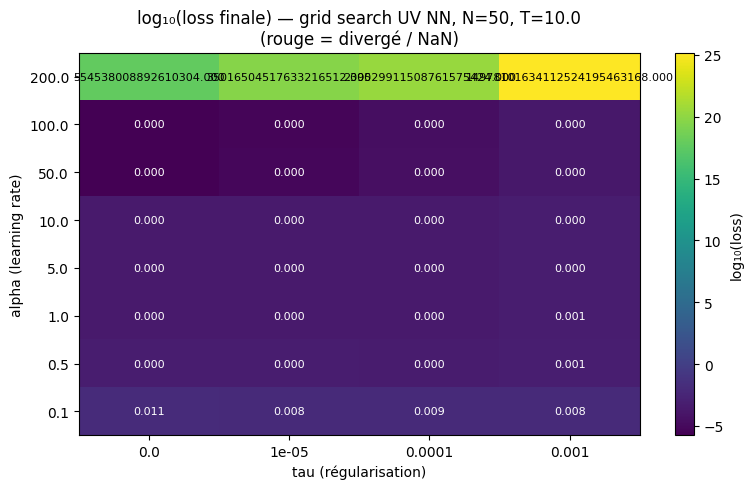


Meilleur config : alpha=100.0, tau=0.0
Loss moyenne    : 0.000002
Loss DEFAULT (alpha=50, tau=1e-4) : 0.000030


In [3]:
# Build loss matrix (rows = alpha, cols = tau)
loss_matrix = np.full((len(ALPHA_VALUES), len(TAU_VALUES)), np.nan)
for i_a, alpha in enumerate(ALPHA_VALUES):
    for i_t, tau in enumerate(TAU_VALUES):
        vals = results_gs[(alpha, tau)]
        if np.any(np.isfinite(vals)):
            loss_matrix[i_a, i_t] = np.nanmean(vals)

log_loss = np.where(np.isfinite(loss_matrix), np.log10(loss_matrix + 1e-12), np.nan)

cmap = plt.cm.viridis.copy()
cmap.set_bad(color="crimson")
vmin, vmax = np.nanmin(log_loss), np.nanmax(log_loss)

fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(log_loss, aspect="auto", origin="lower",
               cmap=cmap, vmin=vmin, vmax=vmax)

ax.set_xticks(range(len(TAU_VALUES)))
ax.set_xticklabels([str(t) for t in TAU_VALUES])
ax.set_yticks(range(len(ALPHA_VALUES)))
ax.set_yticklabels([str(a) for a in ALPHA_VALUES])
ax.set_xlabel("tau (régularisation)")
ax.set_ylabel("alpha (learning rate)")
ax.set_title(f"log₁₀(loss finale) — grid search UV NN, N={N_GS}, T={T_GS}\n(rouge = divergé / NaN)")

for i in range(len(ALPHA_VALUES)):
    for j in range(len(TAU_VALUES)):
        val = loss_matrix[i, j]
        if np.isfinite(val):
            brightness = (log_loss[i, j] - vmin) / max(vmax - vmin, 1e-9)
            txt_color  = "white" if brightness < 0.55 else "black"
            ax.text(j, i, f"{val:.3f}", ha="center", va="center",
                    fontsize=8, color=txt_color)
        else:
            ax.text(j, i, "NaN", ha="center", va="center",
                    fontsize=8, color="white", fontweight="bold")

plt.colorbar(im, ax=ax, label="log₁₀(loss)")
fig.tight_layout()
plt.show()

# Identify best config
best_i, best_j = np.unravel_index(np.nanargmin(loss_matrix), loss_matrix.shape)
BEST_ALPHA = ALPHA_VALUES[best_i]
BEST_TAU   = TAU_VALUES[best_j]
print(f"\nMeilleur config : alpha={BEST_ALPHA}, tau={BEST_TAU}")
print(f"Loss moyenne    : {loss_matrix[best_i, best_j]:.6f}")

# Compare to default
try:
    default_loss = loss_matrix[ALPHA_VALUES.index(50.0), TAU_VALUES.index(1e-4)]
    print(f"Loss DEFAULT (alpha=50, tau=1e-4) : {default_loss:.6f}")
except ValueError:
    print("(alpha=50 ou tau=1e-4 absent du grid)")

---
## 2. Impact du temps d'entraînement T

Avec `(alpha, tau)` optimal, on teste `T` ∈ {1, 2, 5, 10, 20, 40} pour savoir
si UV converge simplement avec plus de temps, ou si le problème est structurel.

In [4]:
T_VALUES = [1.0, 2.0, 5.0, 10.0, 20.0, 40.0]
N_T      = 100

results_T = {t: [] for t in T_VALUES}

for T in T_VALUES:
    cfg = {**DEFAULT_CONFIG, "alpha": BEST_ALPHA, "tau": BEST_TAU,
           "T": T, "gr": 3, "beta": 0.0}
    for rep in range(N_REPS):
        key = jax.random.PRNGKey(rep * 100)
        h = train(teacher_gs, N_T, key, cfg, "si")
        results_T[T].append(h["losses"][-1])
    print(f"T={T:5.1f}  loss={np.mean(results_T[T]):.4e}")

T=  1.0  loss=3.0961e-04
T=  2.0  loss=2.8071e-04
T=  5.0  loss=2.7276e-06
T= 10.0  loss=1.3394e-06
T= 20.0  loss=7.7912e-07
T= 40.0  loss=4.1143e-07


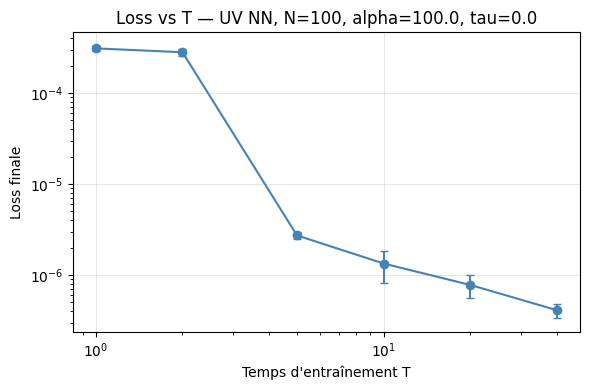

Meilleur T : 40.0


In [5]:
def plot_loss_vs_T(save_pdf=False):
    means = [np.mean(results_T[t]) for t in T_VALUES]
    stds  = [np.std(results_T[t])  for t in T_VALUES]

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.errorbar(T_VALUES, means, yerr=stds, marker="o", capsize=3, color="steelblue")
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("Temps d'entraînement T")
    ax.set_ylabel("Loss finale")
    ax.set_title(f"Loss vs T — UV NN, N={N_T}, alpha={BEST_ALPHA}, tau={BEST_TAU}")
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    if save_pdf:
        fig.savefig(f"uv_loss_vs_T.pdf", format="pdf", bbox_inches="tight")
    plt.show()

plot_loss_vs_T(save_pdf=False)

# Best T = the one giving lowest mean loss
BEST_T = T_VALUES[int(np.argmin([np.mean(results_T[t]) for t in T_VALUES]))]
print(f"Meilleur T : {BEST_T}")

---
## 3. Validation complète — meilleur config vs DEFAULT

On compare le meilleur config avec le DEFAULT sur `N=300`, pour les trois schemes
vanilla / DA / FA avec `gr=20` (courbes lisses).

In [6]:
BEST_CONFIG    = {**DEFAULT_CONFIG, "alpha": BEST_ALPHA, "tau": BEST_TAU,
                  "T": BEST_T, "gr": 20, "beta": 0.0}
DEFAULT_CONFIG_UV = {**DEFAULT_CONFIG, "T": BEST_T, "gr": 20, "beta": 0.0}

print(f"BEST_CONFIG   : alpha={BEST_ALPHA}, tau={BEST_TAU}, T={BEST_T}")
print(f"DEFAULT (ref) : alpha=50, tau=1e-4, T={BEST_T}")

BEST_CONFIG   : alpha=100.0, tau=0.0, T=40.0
DEFAULT (ref) : alpha=50, tau=1e-4, T=40.0


In [7]:
N_VAL      = 300
N_REPS_VAL = 3

teacher_val = make_wi_particles()
hist_best    = {"vanilla": [], "DA": [], "FA": []}
hist_default = {"vanilla": [], "DA": [], "FA": []}

for rep in range(N_REPS_VAL):
    key = jax.random.PRNGKey(rep * 100)

    for fold, cfg, store in [(0, BEST_CONFIG, hist_best),
                              (10, DEFAULT_CONFIG_UV, hist_default)]:
        h = train(teacher_val, N_VAL, jax.random.fold_in(key, fold),   cfg, "si")
        store["vanilla"].append(h)
        h = train(teacher_val, N_VAL, jax.random.fold_in(key, fold+1), cfg, "si", used_loss_fn=loss_fn_da)
        store["DA"].append(h)
        h = train(teacher_val, N_VAL, jax.random.fold_in(key, fold+2), cfg, "si", used_loss_fn=loss_fn_fa)
        store["FA"].append(h)

    print(f"rep {rep} done")

rep 0 done
rep 1 done
rep 2 done


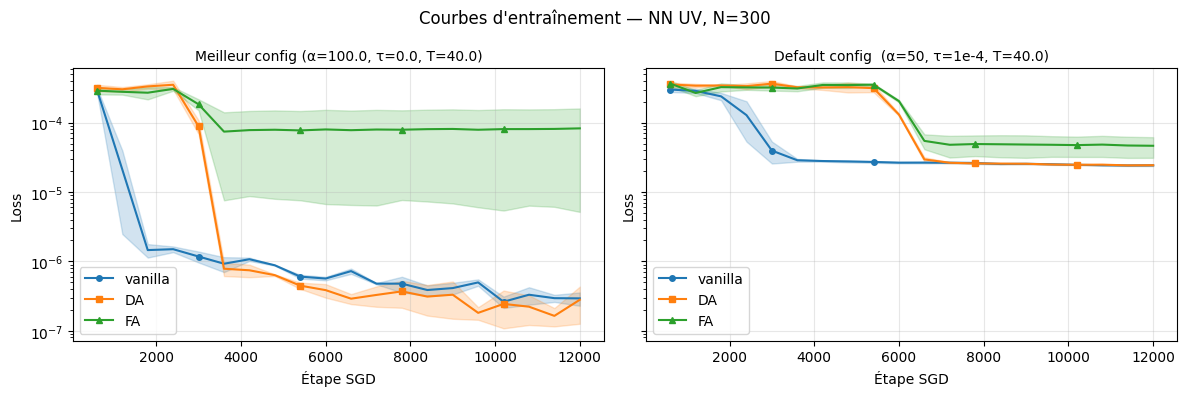

In [8]:
def plot_validation_curves(save_pdf=False):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

    pairs = [
        (hist_best,    f"Meilleur config (α={BEST_ALPHA}, τ={BEST_TAU}, T={BEST_T})", axes[0]),
        (hist_default, f"Default config  (α=50, τ=1e-4, T={BEST_T})",                 axes[1]),
    ]

    for histories, title, ax in pairs:
        for name, hists in histories.items():
            steps       = np.array(hists[0]["steps"][1:])
            loss_mat    = np.stack([np.array(h["losses"]) for h in hists])
            mean, std   = loss_mat.mean(0), loss_mat.std(0)
            color       = DEFAULT_COLORS.get(name)
            n_pts       = len(steps)
            ax.plot(steps, mean, marker=DEFAULT_MARKERS.get(name, "o"),
                    color=color, label=name, markersize=4,
                    markevery=max(1, n_pts // 5))
            ax.fill_between(steps, np.maximum(mean - std, 1e-12), mean + std,
                            alpha=0.2, color=color)
        ax.set_yscale("log")
        ax.set_xlabel("Étape SGD")
        ax.set_ylabel("Loss")
        ax.set_title(title, fontsize=10)
        ax.legend()
        ax.grid(True, alpha=0.3)

    fig.suptitle(f"Courbes d'entraînement — NN UV, N={N_VAL}", fontsize=12)
    fig.tight_layout()
    if save_pdf:
        fig.savefig("uv_validation_training_curves.pdf", format="pdf", bbox_inches="tight")
    plt.show()

plot_validation_curves(save_pdf=False)

---
## 4. Loss vs N — meilleur config vs DEFAULT

Vérification que la loss décroît bien avec N en utilisant le meilleur config,
et comparaison avec le DEFAULT_CONFIG pour quantifier le gain.

In [10]:
N_VALUES  = [5, 10, 50, 100, 300, 500]
N_REPS_N  = 2

cfg_best_N    = {**BEST_CONFIG,       "gr": 3, 'T':15}
cfg_default_N = {**DEFAULT_CONFIG_UV, "gr": 3, 'T':15}

res_best    = {"vanilla": [], "DA": [], "FA": []}
res_default = {"vanilla": [], "DA": [], "FA": []}

for N in N_VALUES:
    for store in [res_best, res_default]:
        for name in store:
            store[name].append([])

    for rep in range(N_REPS_N):
        key = jax.random.PRNGKey(rep * 1000 + N)

        for fold, cfg, store in [(0, cfg_best_N, res_best),
                                  (10, cfg_default_N, res_default)]:
            h = train(teacher_gs, N, jax.random.fold_in(key, fold),   cfg, "si")
            store["vanilla"][-1].append(h["losses"][-1])
            h = train(teacher_gs, N, jax.random.fold_in(key, fold+1), cfg, "si", used_loss_fn=loss_fn_da)
            store["DA"][-1].append(h["losses"][-1])
            h = train(teacher_gs, N, jax.random.fold_in(key, fold+2), cfg, "si", used_loss_fn=loss_fn_fa)
            store["FA"][-1].append(h["losses"][-1])

    print(f"N={N} done")

N=5 done
N=10 done
N=50 done
N=100 done
N=300 done
N=500 done


/var/folders/32/70v0d51s4gx0s73m3z5198600000gn/T/ipykernel_39170/3907435697.py:11: RuntimeWarning: Mean of empty slice
  means = [np.nanmean(r) for r in reps_per_N]
/Users/simonpierre/Documents/4eme_annee/MA2/DOLA_Project/DOLA/.venv/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


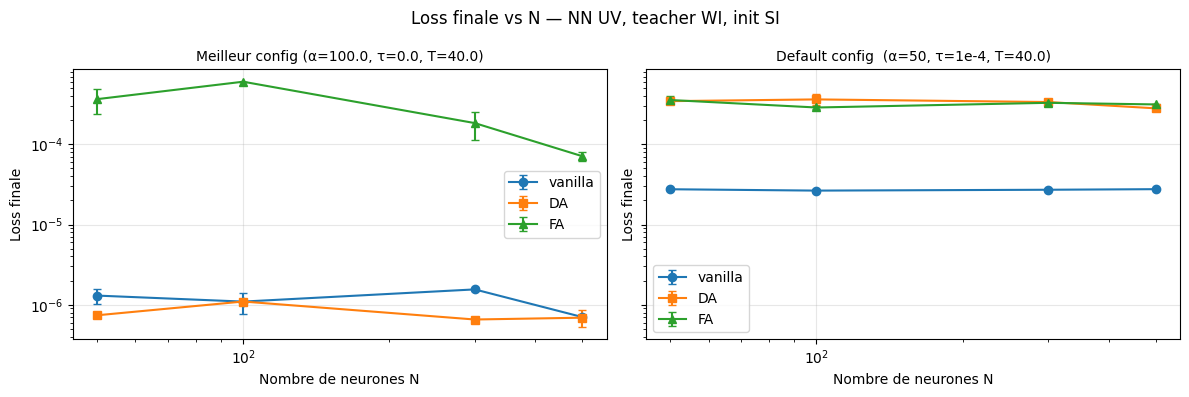

In [11]:
def plot_loss_vs_N_comparison(save_pdf=False):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

    datasets = [
        (res_best,    f"Meilleur config (α={BEST_ALPHA}, τ={BEST_TAU}, T={BEST_T})", axes[0]),
        (res_default, f"Default config  (α=50, τ=1e-4, T={BEST_T})",                axes[1]),
    ]

    for results, title, ax in datasets:
        for name, reps_per_N in results.items():
            means = [np.nanmean(r) for r in reps_per_N]
            stds  = [np.nanstd(r)  for r in reps_per_N]
            ax.errorbar(N_VALUES, means, yerr=stds,
                        marker=DEFAULT_MARKERS.get(name, "o"),
                        color=DEFAULT_COLORS.get(name),
                        label=name, capsize=3)
        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.set_xlabel("Nombre de neurones N")
        ax.set_ylabel("Loss finale")
        ax.set_title(title, fontsize=10)
        ax.legend()
        ax.grid(True, alpha=0.3)

    fig.suptitle("Loss finale vs N — NN UV, teacher WI, init SI", fontsize=12)
    fig.tight_layout()
    if save_pdf:
        fig.savefig("uv_loss_vs_N_comparison.pdf", format="pdf", bbox_inches="tight")
    plt.show()

plot_loss_vs_N_comparison(save_pdf=False)